# Identify contact residues on MHC molecules

## Introduction

In this notebook, we aim to determine the IMGT positions of MHC molecules that make contact with the CDR loops of a contacting TCR. These contacts are then plotted based on the identity of the TCR loop to create a finger print of the TCRs on MHC molecules. We also look at the contacts made by TCRs on the presented peptide.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from Bio.PDB import PDBParser

from tcr_antigen_prediction.structure import bio_to_pandas

In [2]:
IMGT_CDR1 = set(range(27, 38 + 1))
'''IMGT residue numbers corresponding to CDR 1 domains.'''
IMGT_CDR2 = set(range(56, 65 + 1))
'''IMGT residue numbers corresponding to CDR 2 domains.'''
IMGT_CDR3 = set(range(105, 117 + 1))
'''IMGT residue numbers corresponding to CDR 3 domains.'''
IMGT_CDR = IMGT_CDR1.union(IMGT_CDR2).union(IMGT_CDR3)
'''IMGT residue numbers corresponding to all CDR domains.'''

IMGT_VARIABLE_DOMAIN = set(range(1, 128 + 1))
'''Variable domain range for IMGT numbered TCR structures.'''

IMGT_MHC_I_ABD = set(range(1, 92)) | set(range(1001, 1092))
'''IMGT ranges of the antigen binding domain of MHC-I molecules.'''

IMGT_MHC_II_ABD = set(range(1, 92))
'''IMGT ranges of the antigen binding domain of MHC-I molecules.'''


def assign_cdr_number(imgt_id: str | int | None) -> int | None:
    """Map imgt_id to CDR domains.

    Return number associated with domain or return None if input is not in a CDR domain.
    """
    if not imgt_id:
        return None

    seq_id = int(''.join([char for char in imgt_id if char.isnumeric()])) if type(imgt_id) is not int else imgt_id

    if seq_id in IMGT_CDR1:
        return 1

    if seq_id in IMGT_CDR2:
        return 2

    if seq_id in IMGT_CDR3:
        return 3

    return None

In [3]:
CUTOFF_DISTANCE = 5  # Å

In [4]:
STCRDAB_PATH = 'data/raw/stcrdab'
stcrdab_summary = pd.read_csv(os.path.join(STCRDAB_PATH, 'db_summary.dat'), delimiter='\t')

## TCR:pMHC-I

### Loading TCR:pMHC-I Structures

In [5]:
selected_stcrdab_class_i = stcrdab_summary.copy()

# Resolution better than 3.50 Å
selected_stcrdab_class_i['resolution'] = pd.to_numeric(selected_stcrdab_class_i['resolution'], errors='coerce')
selected_stcrdab_class_i = selected_stcrdab_class_i.query('resolution <= 3.50')

# alpha-beta TCRs
selected_stcrdab_class_i = selected_stcrdab_class_i.query("TCRtype == 'abTCR'")

# MHC class I
selected_stcrdab_class_i = selected_stcrdab_class_i.query("mhc_type == 'MH1'")

# peptide antigen
selected_stcrdab_class_i = selected_stcrdab_class_i.query("antigen_type == 'peptide'")

# General clean: drop columns that don't contain anything useful
selected_stcrdab_class_i = selected_stcrdab_class_i.loc[
    :,
    selected_stcrdab_class_i.apply(
        lambda col: not col.duplicated().all(),
    ),
]
selected_stcrdab_class_i = selected_stcrdab_class_i.dropna(axis=1, how='all')

# Reset Index
selected_stcrdab_class_i = selected_stcrdab_class_i.reset_index(drop=True)

selected_stcrdab_class_i

,pdb,Bchain,Achain,TCRtype,model,antigen_chain,antigen_type,antigen_name,mhc_type,mhc_chain1,...,alpha_organism,antigen_organism,mhc_chain1_organism,mhc_chain2_organism,authors,resolution,method,r_free,r_factor,engineered
0,2ak4,E,D,abTCR,0,C,peptide,ebv peptide lpeplpqgqltay,MH1,A,...,homo sapiens,NaN,homo sapiens,homo sapiens,"Tynan, F.E., Burrows, S.R., Buckle, A.M., Clem...",2.50,X-RAY DIFFRACTION,0.278,0.246,True
1,7nme,E,D,abTCR,0,C,peptide,gln-leu-pro-arg-leu-phe-pro-leu-leu,MH1,A,...,homo sapiens,homo sapiens,homo sapiens,homo sapiens,"Rizkallah, P.J., Sewell, A.K., Cole, D.K., Wal...",2.20,X-RAY DIFFRACTION,0.274,0.215,True
2,5eu6,E,D,abTCR,0,C,peptide,tyr-leu-glu-pro-gly-pro-val-thr-val,MH1,A,...,homo sapiens,synthetic construct,homo sapiens,homo sapiens,"Rizkallah, P.J., Bianchi, V., Cole, D.K., Sewe...",2.02,X-RAY DIFFRACTION,0.222,0.181,True
3,7pbe,J,I,abTCR,0,H,peptide,spike protein s1,MH1,F,...,homo sapiens,severe acute respiratory syndrome coronavirus2,homo sapiens,homo sapiens,"Rizkallah, P.J., Sewell, A.K., Wall, A., Fulle...",3.00,X-RAY DIFFRACTION,0.296,0.228,True
4,8eo8,E,D,abTCR,0,C,peptide,nucleoprotein np8 epitope,MH1,A,...,homo sapiens,influenza a virus,homo sapiens,homo sapiens,"Littler, D.R., Rossjohn, J.",2.30,X-RAY DIFFRACTION,0.219,0.181,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,6q3s,E,D,abTCR,0,C,peptide,ser-leu-leu-met-trp-ile-thr-gln-val,MH1,A,...,homo sapiens,homo sapiens,homo sapiens,homo sapiens,"Meijers, R., Anjanappa, R., Springer, S., Garc...",2.50,X-RAY DIFFRACTION,0.273,0.229,True
329,5men,E,D,abTCR,0,C,peptide,ile-leu-ala-lys-phe-leu-his-trp-leu,MH1,A,...,homo sapiens,homo sapiens,homo sapiens,homo sapiens,"Rizkallah, P.J., Lloyd, A., Crowther, M., Cole...",2.81,X-RAY DIFFRACTION,0.272,0.189,True
330,3vxu,J,I,abTCR,0,H,peptide,10-mer peptide from protein nef,MH1,F,...,homo sapiens,human immunodeficiency virus 1,homo sapiens,homo sapiens,"Shimizu, A., Fukai, S., Yamagata, A., Iwamoto, A.",2.70,X-RAY DIFFRACTION,0.323,0.272,True
331,8dnt,I,H,abTCR,0,J,peptide,nucleoprotein,MH1,K,...,homo sapiens,severe acute respiratory syndrome coronavirus2,homo sapiens,homo sapiens,"Gallagher, D.T., Wu, D., Gowthaman, R., Pierce...",3.18,X-RAY DIFFRACTION,0.313,0.221,True


### Determine contacting residues

In [6]:
pdb_parser = PDBParser(QUIET=True)

mhc_i_contacts = []

for _, row in selected_stcrdab_class_i.iterrows():
    path = os.path.join(STCRDAB_PATH, 'imgt', f'{row.pdb}.pdb')

    structure = pdb_parser.get_structure('', path)
    structure_df = bio_to_pandas(structure)

    chain_annotations = {}
    chain_annotations[row.Achain] = 'alpha_chain'
    chain_annotations[row.Bchain] = 'beta_chain'
    chain_annotations[row.antigen_chain] = 'antigen_chain'
    chain_annotations[row.mhc_chain1] = 'mhc_chain'

    structure_df['chain_type'] = structure_df['chain_id'].map(
        lambda id_, chain_annotations=chain_annotations: chain_annotations.get(id_, None),
    )
    structure_df['cdr'] = structure_df['residue_seq_id'].map(assign_cdr_number)

    mhc_df = structure_df.query("chain_type == 'mhc_chain' and residue_seq_id in @IMGT_MHC_I_ABD")
    peptide_df = structure_df.query("chain_type == 'antigen_chain'").copy()
    tcr_cdrs_df = structure_df.query("(chain_type == 'alpha_chain' or chain_type == 'beta_chain') and cdr.notna()")

    peptide_df_per_res = peptide_df.groupby(['residue_seq_id', 'residue_insert_code', 'residue_name'], dropna=False)
    group_mapping = {group: idx for idx, group in enumerate(peptide_df_per_res.groups.keys(), 1)}

    peptide_df['peptide_length'] = max(group_mapping.values())
    peptide_df['peptide_position'] = (
        peptide_df[['residue_seq_id', 'residue_insert_code', 'residue_name']]
        .apply(tuple, axis='columns')
        .map(group_mapping)
    )

    tcr_mhc_interface = tcr_cdrs_df.merge(mhc_df, how='cross', suffixes=('_tcr', '_mhc'))
    tcr_mhc_interface['distance'] = np.sqrt(
        np.square(tcr_mhc_interface['pos_x_tcr'] - tcr_mhc_interface['pos_x_mhc'])
        + np.square(tcr_mhc_interface['pos_y_tcr'] - tcr_mhc_interface['pos_y_mhc'])
        + np.square(tcr_mhc_interface['pos_z_tcr'] - tcr_mhc_interface['pos_z_mhc'])
    )

    tcr_peptide_interface = tcr_cdrs_df.merge(peptide_df, how='cross', suffixes=('_tcr', '_peptide'))
    tcr_peptide_interface['distance'] = np.sqrt(
        np.square(tcr_peptide_interface['pos_x_tcr'] - tcr_peptide_interface['pos_x_peptide'])
        + np.square(tcr_peptide_interface['pos_y_tcr'] - tcr_peptide_interface['pos_y_peptide'])
        + np.square(tcr_peptide_interface['pos_z_tcr'] - tcr_peptide_interface['pos_z_peptide'])
    )

    contacts_tcr_mhc = tcr_mhc_interface.query('distance < @CUTOFF_DISTANCE').copy()
    contacts_tcr_mhc['path'] = path
    contacts_tcr_mhc['interface_type'] = 'tcr_mhc'
    mhc_i_contacts.append(contacts_tcr_mhc)

    contacts_tcr_peptide = tcr_peptide_interface.query('distance < @CUTOFF_DISTANCE').copy()
    contacts_tcr_peptide['path'] = path
    contacts_tcr_peptide['interface_type'] = 'tcr_peptide'
    mhc_i_contacts.append(contacts_tcr_peptide)

mhc_i_contacts = pd.concat(mhc_i_contacts)
mhc_i_contacts

,record_type_tcr,atom_number_tcr,atom_name_tcr,alt_loc_tcr,residue_name_tcr,chain_id_tcr,residue_seq_id_tcr,residue_insert_code_tcr,pos_x_tcr,pos_y_tcr,...,pos_y_peptide,pos_z_peptide,occupancy_peptide,b_factor_peptide,element_peptide,charge_peptide,chain_type_peptide,cdr_peptide,peptide_length,peptide_position
46415,ATOM,612,CG,None,ASN,E,37,None,9.816,4.380000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47892,ATOM,613,OD1,None,ASN,E,37,None,10.277,5.181000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47893,ATOM,613,OD1,None,ASN,E,37,None,10.277,5.181000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47894,ATOM,613,OD1,None,ASN,E,37,None,10.277,5.181000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49373,ATOM,614,ND2,None,ASN,E,37,None,9.745,3.073000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31515,ATOM,10078,CD2,None,TYR,N,113,None,-51.375,74.966003,...,73.846001,-3.678,1.0,63.86,O,None,antigen_chain,NaN,10.0,4.0
31516,ATOM,10078,CD2,None,TYR,N,113,None,-51.375,74.966003,...,75.095001,-6.148,1.0,63.91,C,None,antigen_chain,NaN,10.0,4.0
31517,ATOM,10078,CD2,None,TYR,N,113,None,-51.375,74.966003,...,76.511002,-6.671,1.0,63.85,C,None,antigen_chain,NaN,10.0,4.0
31697,ATOM,10080,CE2,None,TYR,N,113,None,-52.313,73.947998,...,73.846001,-3.678,1.0,63.86,O,None,antigen_chain,NaN,10.0,4.0


In [7]:
mhc_i_contacts['pdb_id'] = mhc_i_contacts['path'].map(lambda path: path.split('/')[-1].split('.')[0])

In [8]:
def create_resi(seq_id: float, insert_code: str | float) -> str | None:
    if pd.isna(seq_id):
        return None

    return str(int(seq_id)) + (insert_code if not pd.isna(insert_code) else '')


mhc_i_contacts['resi_mhc'] = mhc_i_contacts.apply(
    lambda row: create_resi(row.residue_seq_id_mhc, row.residue_insert_code_mhc),
    axis='columns',
)
mhc_i_contacts['resi_tcr'] = mhc_i_contacts.apply(
    lambda row: create_resi(row.residue_seq_id_tcr, row.residue_insert_code_tcr),
    axis='columns',
)

In [9]:
mhc_i_contacts.loc[mhc_i_contacts['peptide_position'].notna(), 'peptide_position'] = (
    mhc_i_contacts.loc[mhc_i_contacts['peptide_position'].notna(), 'peptide_position'].apply(int).apply(str)
)

/var/scratch/bmcmaste/2399326/ipykernel_2018683/404438514.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['9' '9' '9' ... '4' '4' '4']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mhc_i_contacts.loc[mhc_i_contacts['peptide_position'].notna(),


In [10]:
mhc_i_contacts['cdr_name'] = mhc_i_contacts.apply(
    lambda row: f"CDR-{'A' if row.chain_type_tcr == 'alpha_chain' else 'B'}{int(row.cdr_tcr)}",
    axis='columns',
)

In [11]:
mhc_i_contacts['cdr_name'] = pd.Categorical(
    mhc_i_contacts['cdr_name'], ['CDR-A1', 'CDR-A2', 'CDR-A3', 'CDR-B1', 'CDR-B2', 'CDR-B3']
)

### Visualising contact maps

In [12]:
palette = sns.color_palette(
    ['#' + colour.lower() for colour in ['DC91BE', 'C0C0C2', '6490C7', '963E87', '2D2E62', '56BBD3']], 6
)

#### TCR Contacts on MHC Molecules

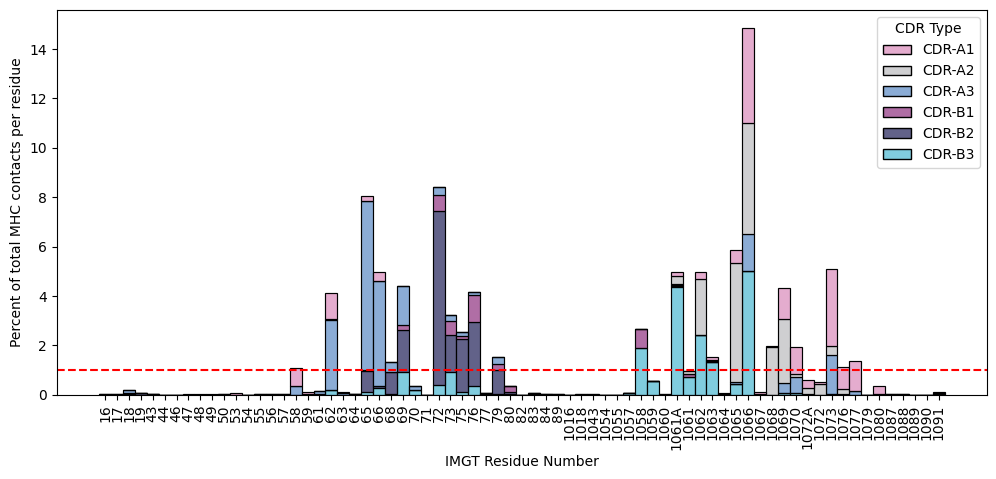

In [13]:
plt.figure(figsize=(12, 5))

ax = sns.histplot(
    mhc_i_contacts.query("interface_type == 'tcr_mhc'").sort_values('residue_seq_id_mhc'),
    x='resi_mhc',
    hue='cdr_name',
    multiple='stack',
    stat='percent',
    palette=palette,
)

xlims = ax.get_xlim()
ax.set_xlim(*xlims)

ax.hlines(1, *xlims, color='red', linestyle='dashed')

ax.legend_.set_title(title='CDR Type')
ax.set_xlabel('IMGT Residue Number')
ax.set_ylabel('Percent of total MHC contacts per residue')
plt.xticks(rotation=90)

plt.show()

In [14]:
mhc_labels = (
    mhc_i_contacts[['residue_seq_id_mhc', 'residue_insert_code_mhc', 'resi_mhc']]
    .fillna('')
    .sort_values(['residue_seq_id_mhc', 'residue_insert_code_mhc'])['resi_mhc']
    .unique()
    .tolist()
)

tcr_labels = (
    mhc_i_contacts[['residue_seq_id_tcr', 'residue_insert_code_tcr', 'resi_tcr']]
    .fillna('')
    .sort_values(['residue_seq_id_tcr', 'residue_insert_code_tcr'])['resi_tcr']
    .unique()
    .tolist()
)

mhc_i_contacts['resi_mhc'] = pd.Categorical(mhc_i_contacts['resi_mhc'], mhc_labels)
mhc_i_contacts['resi_tcr'] = pd.Categorical(mhc_i_contacts['resi_tcr'], tcr_labels)

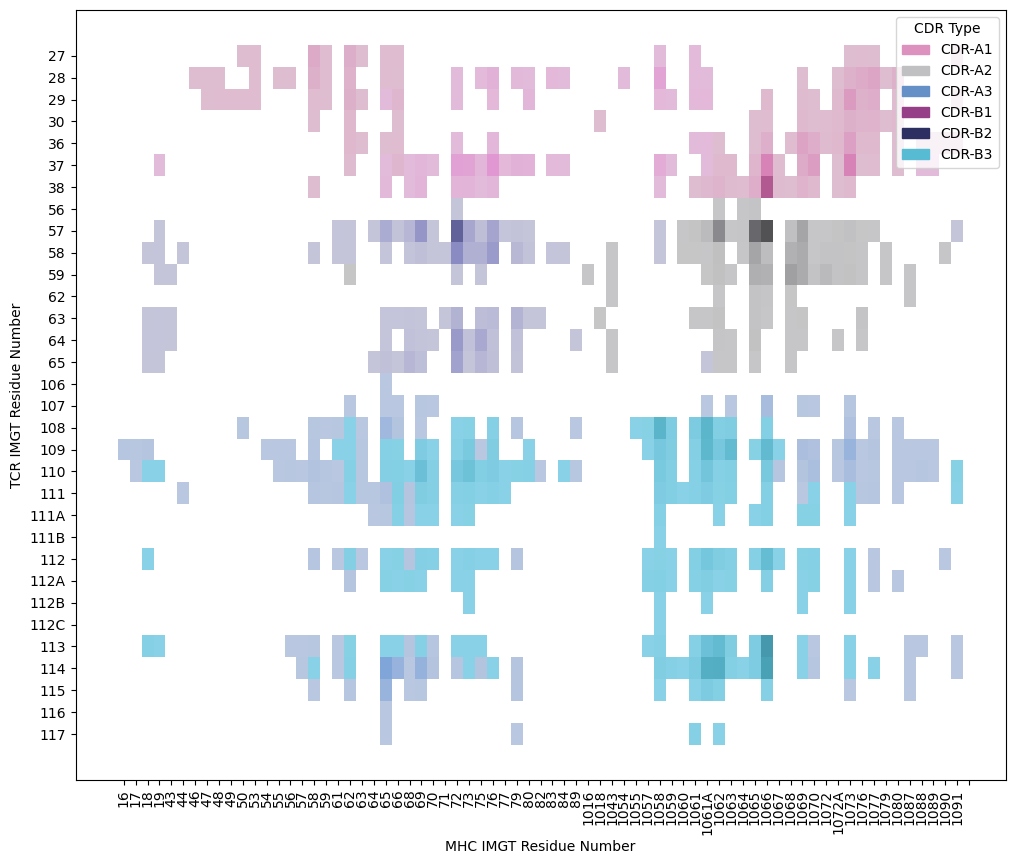

In [15]:
plt.figure(figsize=(12, 10))

ax = sns.histplot(
    mhc_i_contacts.query("interface_type == 'tcr_mhc'"),
    x='resi_mhc',
    y='resi_tcr',
    hue='cdr_name',
    palette=sns.color_palette(palette, 6),
)

ax.legend_.set_title(title='CDR Type')
ax.set_xlabel('MHC IMGT Residue Number')
ax.set_ylabel('TCR IMGT Residue Number')
plt.xticks(rotation=90)

plt.show()

#### TCR Contacts on Peptides

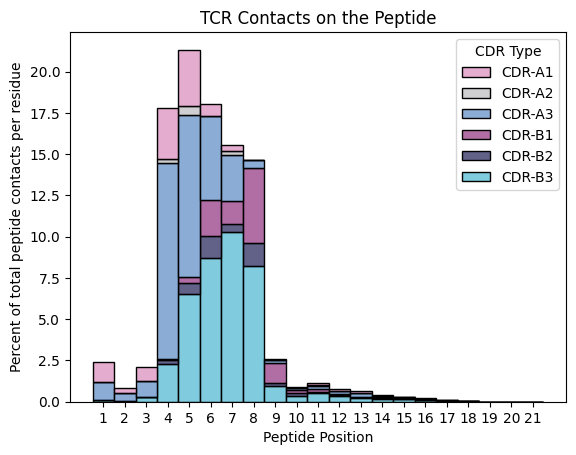

In [16]:
ax = sns.histplot(
    mhc_i_contacts.query("interface_type == 'tcr_peptide'").sort_values('residue_seq_id_peptide'),
    x='peptide_position',
    hue='cdr_name',
    multiple='stack',
    stat='percent',
    palette=sns.color_palette(palette, 6),
)

ax.set_title('TCR Contacts on the Peptide')
ax.set_xlabel('Peptide Position')
ax.set_ylabel('Percent of total peptide contacts per residue')
ax.legend_.set_title(title='CDR Type')

plt.show()

<Axes: xlabel='peptide_length', ylabel='Count'>

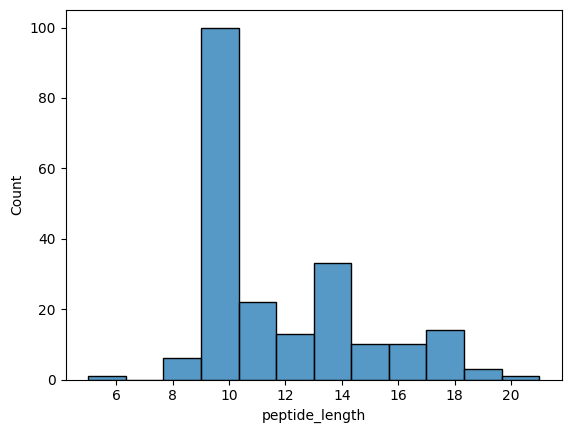

In [17]:
sns.histplot(mhc_i_contacts.query("interface_type == 'tcr_peptide'").drop_duplicates('path'), x='peptide_length')

The mode of peptide lengths in 9-mers!

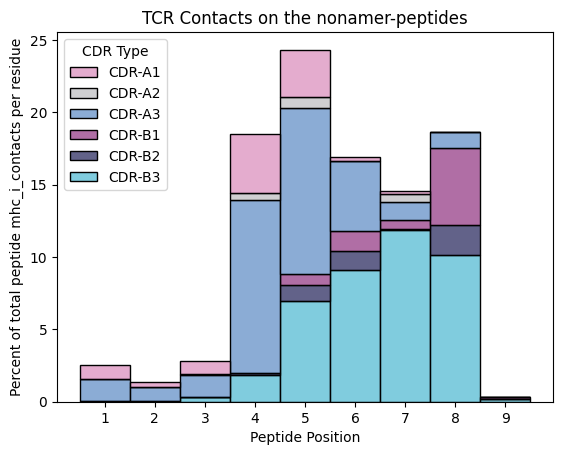

In [18]:
ax = sns.histplot(
    mhc_i_contacts.query(
        "interface_type == 'tcr_peptide' and peptide_length == 9.0",
    ).sort_values('residue_seq_id_peptide'),
    x='peptide_position',
    hue='cdr_name',
    multiple='stack',
    stat='percent',
    palette=sns.color_palette(palette, 6),
)

ax.set_title('TCR Contacts on the nonamer-peptides')
ax.set_xlabel('Peptide Position')
ax.set_ylabel('Percent of total peptide mhc_i_contacts per residue')
ax.legend_.set_title(title='CDR Type')

plt.show()

For the nonamers, which is the dominant contacting loop at each peptide position?

In [19]:
def select_dominant(group: pd.DataFrame) -> str:
    return group.sort_values('count', ascending=False).iloc[0]['cdr_name']


nonanmer_peptide_tcr_contact_counts = mhc_i_contacts.query(
    "interface_type == 'tcr_peptide' and peptide_length == 9.0",
).value_counts(['peptide_position', 'cdr_name'])
nonanmer_peptide_tcr_contact_counts.name = 'count'
nonanmer_peptide_tcr_contact_counts = nonanmer_peptide_tcr_contact_counts.reset_index()

nonanmer_peptide_tcr_contact_counts.groupby('peptide_position').apply(select_dominant)

/var/scratch/bmcmaste/2399326/ipykernel_2018683/1262812656.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nonanmer_peptide_tcr_contact_counts.groupby('peptide_position').apply(select_dominant)


peptide_position
1    CDR-A3
2    CDR-A3
3    CDR-A3
4    CDR-A3
5    CDR-A3
6    CDR-B3
7    CDR-B3
8    CDR-B3
9    CDR-B3
dtype: object

Do the non-nonamers have the same trend?

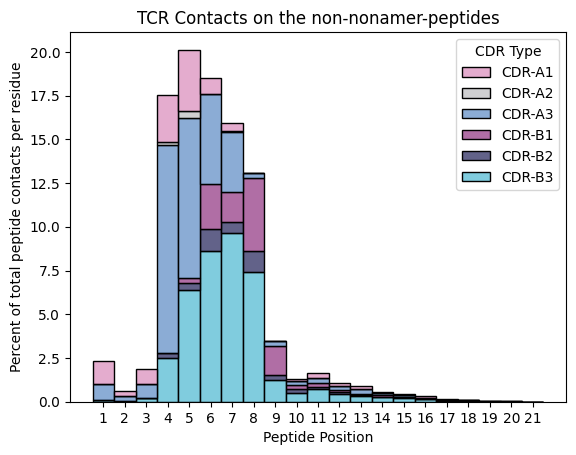

In [20]:
ax = sns.histplot(
    mhc_i_contacts.query(
        "interface_type == 'tcr_peptide' and peptide_length != 9.0",
    ).sort_values('residue_seq_id_peptide'),
    x='peptide_position',
    hue='cdr_name',
    multiple='stack',
    stat='percent',
    palette=sns.color_palette(palette, 6),
)

ax.set_title('TCR Contacts on the non-nonamer-peptides')
ax.set_xlabel('Peptide Position')
ax.set_ylabel('Percent of total peptide contacts per residue')
ax.legend_.set_title(title='CDR Type')

plt.show()

Yes, it seems that they do.

### Exporting residue list

#### Remove Noise

In [21]:
mhc_i_contact_positions = mhc_i_contacts.value_counts(['cdr_name', 'resi_mhc'], normalize=True) * 100
mhc_i_contact_positions.name = 'percentage'
mhc_i_contact_positions = (
    mhc_i_contact_positions.to_frame().reset_index().sort_values('resi_mhc').reset_index(drop=True)
)

In [22]:
mhc_i_contact_positions['cumulative_percentage'] = mhc_i_contact_positions.groupby('resi_mhc')['percentage'].transform(
    'sum'
)

mhc_i_contact_positions = mhc_i_contact_positions[mhc_i_contact_positions['cumulative_percentage'] >= 1.0]
mhc_i_contact_positions = mhc_i_contact_positions.reset_index(drop=True)
mhc_i_contact_positions = mhc_i_contact_positions.drop(columns=['cumulative_percentage'])

/var/scratch/bmcmaste/2399326/ipykernel_2018683/2151035588.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mhc_i_contact_positions['cumulative_percentage'] = (mhc_i_contact_positions.groupby('resi_mhc')


In [23]:
mhc_i_contact_positions

,cdr_name,resi_mhc,percentage
0,CDR-B2,58,0.003780
1,CDR-A3,58,0.345893
2,CDR-A1,58,0.734314
3,CDR-B3,58,0.005670
4,CDR-A3,62,2.851256
...,...,...,...
88,CDR-A1,1076,0.905371
89,CDR-A1,1077,1.179439
90,CDR-A2,1077,0.000945
91,CDR-A3,1077,0.171056


In [24]:
mhc_i_contact_positions.to_csv('data/interim/tcr_mhc_class_I_contacts.csv', index=False)

## TCR:pMHC-II

In [25]:
selected_stcrdab_class_ii = stcrdab_summary.copy()

# Resolution better than 3.50 Å
selected_stcrdab_class_ii['resolution'] = pd.to_numeric(selected_stcrdab_class_ii['resolution'], errors='coerce')
selected_stcrdab_class_ii = selected_stcrdab_class_ii.query('resolution <= 3.50')

# alpha-beta TCRs
selected_stcrdab_class_ii = selected_stcrdab_class_ii.query("TCRtype == 'abTCR'")

# MHC class II
selected_stcrdab_class_ii = selected_stcrdab_class_ii.query("mhc_type == 'MH2'")

# peptide antigen
selected_stcrdab_class_ii = selected_stcrdab_class_ii.query("antigen_type == 'peptide'")

# General clean: drop columns that don't contain anything useful
selected_stcrdab_class_ii = selected_stcrdab_class_ii.loc[
    :,
    selected_stcrdab_class_ii.apply(
        lambda col: not col.duplicated().all(),
    ),
]
selected_stcrdab_class_ii = selected_stcrdab_class_ii.dropna(axis=1, how='all')

# Reset Index
selected_stcrdab_class_ii = selected_stcrdab_class_ii.reset_index(drop=True)

selected_stcrdab_class_ii

,pdb,Bchain,Achain,TCRtype,model,antigen_chain,antigen_type,antigen_name,mhc_type,mhc_chain1,...,alpha_organism,antigen_organism,mhc_chain1_organism,mhc_chain2_organism,authors,resolution,method,r_free,r_factor,engineered
0,4ozi,H,G,abTCR,0,J,peptide,deamidated gliadin-alpha1 peptide,MH2,A,...,homo sapiens,triticum aestivum,homo sapiens,homo sapiens,"Petersen, J., Reid, H.H., Rossjohn, J.",3.200,X-RAY DIFFRACTION,0.243,0.213,True
1,6v18,E,D,abTCR,0,C,peptide,fibrinogen beta,MH2,A,...,mus musculus,homo sapiens,homo sapiens,homo sapiens,"Lim, J.J., Rossjohn, J.",2.350,X-RAY DIFFRACTION,0.231,0.193,True
2,7t2b,T,S,abTCR,0,R,peptide,pneumolysin-derived peptide,MH2,P,...,homo sapiens,streptococcus pneumoniae,homo sapiens,homo sapiens,"Ciacchi, L., Farenc, C., Petersen, J., Reid, H...",2.800,X-RAY DIFFRACTION,0.250,0.216,True
3,7sg1,J,I,abTCR,0,H,peptide,dq2-glia-alpha1a peptide,MH2,F,...,homo sapiens,homo sapiens,homo sapiens,homo sapiens,"Ciacchi, L., Farenc, C., Petersen, J., Reid, H...",3.100,X-RAY DIFFRACTION,0.258,0.217,True
4,4p2o,D,C,abTCR,0,P,peptide,2a peptide,MH2,A,...,mus musculus,synthetic construct,mus musculus,mus musculus,"Birnbaum, M.E., Ozkan, E., Garcia, K.C.",2.603,X-RAY DIFFRACTION,0.245,0.189,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,6cqq,J,I,abTCR,0,H,peptide,peptide from capsid protein p24,MH2,F,...,homo sapiens,hiv-1 m,homo sapiens,homo sapiens,"Farenc, C., Gras, S., Rossjohn, J.",2.800,X-RAY DIFFRACTION,0.254,0.207,True
82,4ozf,H,G,abTCR,0,J,peptide,deamidated gliadin-alpha2 peptide,MH2,A,...,homo sapiens,triticum aestivum,homo sapiens,homo sapiens,"Petersen, J., Reid, H.H., Rossjohn, J.",2.700,X-RAY DIFFRACTION,0.238,0.184,True
83,7sg2,E,D,abTCR,0,C,peptide,dq2-glia-omega1 peptide,MH2,A,...,homo sapiens,homo sapiens,homo sapiens,homo sapiens,"Ciacchi, L., Farenc, C., Petersen, J., Reid, H...",3.100,X-RAY DIFFRACTION,0.259,0.218,True
84,1d9k,B,A,abTCR,0,P,peptide,conalbumin peptide,MH2,C,...,mus musculus,mus musculus,mus musculus,mus musculus,"Reinherz, E.L., Tan, K., Tang, L., Kern, P., L...",3.200,X-RAY DIFFRACTION,0.293,0.247,True


### Determine contacting residues

In [26]:
pdb_parser = PDBParser(QUIET=True)
mhc_ii_contacts = []

for _, row in selected_stcrdab_class_ii.iterrows():
    path = os.path.join(STCRDAB_PATH, 'imgt', f'{row.pdb}.pdb')

    structure = pdb_parser.get_structure('', path)
    structure_df = bio_to_pandas(structure)

    chain_annotations = {}
    chain_annotations[row.Achain] = 'alpha_chain'
    chain_annotations[row.Bchain] = 'beta_chain'
    chain_annotations[row.antigen_chain] = 'antigen_chain'
    chain_annotations[row.mhc_chain1] = 'mhc_chain1'
    chain_annotations[row.mhc_chain2] = 'mhc_chain2'

    structure_df['chain_type'] = structure_df['chain_id'].map(
        lambda id_, chain_annotations=chain_annotations: chain_annotations.get(id_, None),
    )
    structure_df['cdr'] = structure_df['residue_seq_id'].map(assign_cdr_number)

    mhc_adb_df = structure_df.query(
        "(chain_type == 'mhc_chain1' or chain_type == 'mhc_chain2') and residue_seq_id in @IMGT_MHC_II_ABD"
    )
    peptide_df = structure_df.query("chain_type == 'antigen_chain'").copy()
    tcr_cdrs_df = structure_df.query("(chain_type == 'alpha_chain' or chain_type == 'beta_chain') and cdr.notna()")

    peptide_df_per_res = peptide_df.groupby(['residue_seq_id', 'residue_insert_code', 'residue_name'], dropna=False)
    group_mapping = {group: idx for idx, group in enumerate(peptide_df_per_res.groups.keys(), 1)}

    peptide_df['peptide_length'] = max(group_mapping.values())
    peptide_df['peptide_position'] = (
        peptide_df[['residue_seq_id', 'residue_insert_code', 'residue_name']]
        .apply(tuple, axis='columns')
        .map(group_mapping)
    )

    tcr_mhc_abd_interface = tcr_cdrs_df.merge(mhc_adb_df, how='cross', suffixes=('_tcr', '_mhc'))
    tcr_mhc_abd_interface['distance'] = np.sqrt(
        np.square(tcr_mhc_abd_interface['pos_x_tcr'] - tcr_mhc_abd_interface['pos_x_mhc'])
        + np.square(tcr_mhc_abd_interface['pos_y_tcr'] - tcr_mhc_abd_interface['pos_y_mhc'])
        + np.square(tcr_mhc_abd_interface['pos_z_tcr'] - tcr_mhc_abd_interface['pos_z_mhc'])
    )

    tcr_peptide_interface = tcr_cdrs_df.merge(peptide_df, how='cross', suffixes=('_tcr', '_peptide'))
    tcr_peptide_interface['distance'] = np.sqrt(
        np.square(tcr_peptide_interface['pos_x_tcr'] - tcr_peptide_interface['pos_x_peptide'])
        + np.square(tcr_peptide_interface['pos_y_tcr'] - tcr_peptide_interface['pos_y_peptide'])
        + np.square(tcr_peptide_interface['pos_z_tcr'] - tcr_peptide_interface['pos_z_peptide'])
    )

    contacts_tcr_mhc_abd = tcr_mhc_abd_interface.query('distance < @CUTOFF_DISTANCE').copy()
    contacts_tcr_mhc_abd['path'] = path
    contacts_tcr_mhc_abd['interface_type'] = 'tcr_mhc'
    mhc_ii_contacts.append(contacts_tcr_mhc_abd)

    contacts_tcr_peptide = tcr_peptide_interface.query('distance < @CUTOFF_DISTANCE').copy()
    contacts_tcr_peptide['path'] = path
    contacts_tcr_peptide['interface_type'] = 'tcr_peptide'
    mhc_ii_contacts.append(contacts_tcr_peptide)

mhc_ii_contacts = pd.concat(mhc_ii_contacts)
mhc_ii_contacts

,record_type_tcr,atom_number_tcr,atom_name_tcr,alt_loc_tcr,residue_name_tcr,chain_id_tcr,residue_seq_id_tcr,residue_insert_code_tcr,pos_x_tcr,pos_y_tcr,...,pos_y_peptide,pos_z_peptide,occupancy_peptide,b_factor_peptide,element_peptide,charge_peptide,chain_type_peptide,cdr_peptide,peptide_length,peptide_position
5397,ATOM,6685,O,None,ASP,H,27,None,245.996002,-33.855000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13965,ATOM,6691,CA,None,PHE,H,28,None,247.432999,-32.756001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18249,ATOM,6694,CB,None,PHE,H,28,None,246.811005,-31.341999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33384,ATOM,6705,CB,None,GLN,H,29,None,248.675995,-33.543999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33385,ATOM,6705,CB,None,GLN,H,29,None,248.675995,-33.543999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29944,ATOM,5940,NH2,None,ARG,G,110,None,-4.789000,34.231998,...,34.816002,-29.596001,1.0,35.34,N,None,antigen_chain,NaN,13.0,4.0
29945,ATOM,5940,NH2,None,ARG,G,110,None,-4.789000,34.231998,...,33.473999,-29.908001,1.0,33.41,C,None,antigen_chain,NaN,13.0,4.0
29946,ATOM,5940,NH2,None,ARG,G,110,None,-4.789000,34.231998,...,32.581001,-30.281000,1.0,31.26,C,None,antigen_chain,NaN,13.0,4.0
29948,ATOM,5940,NH2,None,ARG,G,110,None,-4.789000,34.231998,...,31.433001,-30.898001,1.0,29.60,N,None,antigen_chain,NaN,13.0,5.0


In [27]:
mhc_ii_contacts['pdb_id'] = mhc_ii_contacts['path'].map(lambda path: path.split('/')[-1].split('.')[0])

In [28]:
mhc_ii_contacts['resi_mhc'] = mhc_ii_contacts.apply(
    lambda row: create_resi(row.residue_seq_id_mhc, row.residue_insert_code_mhc),
    axis='columns',
)
mhc_ii_contacts['resi_tcr'] = mhc_ii_contacts.apply(
    lambda row: create_resi(row.residue_seq_id_tcr, row.residue_insert_code_tcr),
    axis='columns',
)

In [29]:
mhc_ii_contacts

,record_type_tcr,atom_number_tcr,atom_name_tcr,alt_loc_tcr,residue_name_tcr,chain_id_tcr,residue_seq_id_tcr,residue_insert_code_tcr,pos_x_tcr,pos_y_tcr,...,b_factor_peptide,element_peptide,charge_peptide,chain_type_peptide,cdr_peptide,peptide_length,peptide_position,pdb_id,resi_mhc,resi_tcr
5397,ATOM,6685,O,None,ASP,H,27,None,245.996002,-33.855000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4ozi,58,27
13965,ATOM,6691,CA,None,PHE,H,28,None,247.432999,-32.756001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4ozi,58,28
18249,ATOM,6694,CB,None,PHE,H,28,None,246.811005,-31.341999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4ozi,58,28
33384,ATOM,6705,CB,None,GLN,H,29,None,248.675995,-33.543999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4ozi,76,29
33385,ATOM,6705,CB,None,GLN,H,29,None,248.675995,-33.543999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4ozi,76,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29944,ATOM,5940,NH2,None,ARG,G,110,None,-4.789000,34.231998,...,35.34,N,None,antigen_chain,NaN,13.0,4.0,4gg6,None,110
29945,ATOM,5940,NH2,None,ARG,G,110,None,-4.789000,34.231998,...,33.41,C,None,antigen_chain,NaN,13.0,4.0,4gg6,None,110
29946,ATOM,5940,NH2,None,ARG,G,110,None,-4.789000,34.231998,...,31.26,C,None,antigen_chain,NaN,13.0,4.0,4gg6,None,110
29948,ATOM,5940,NH2,None,ARG,G,110,None,-4.789000,34.231998,...,29.60,N,None,antigen_chain,NaN,13.0,5.0,4gg6,None,110


In [30]:
mhc_ii_contacts.loc[mhc_ii_contacts['peptide_position'].notna(), 'peptide_position'] = (
    mhc_ii_contacts.loc[mhc_ii_contacts['peptide_position'].notna(), 'peptide_position'].apply(int).apply(str)
)

/var/scratch/bmcmaste/2399326/ipykernel_2018683/2689540575.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['9' '9' '10' ... '4' '5' '7']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mhc_ii_contacts.loc[mhc_ii_contacts['peptide_position'].notna(),


In [31]:
mhc_ii_contacts['cdr_name'] = mhc_ii_contacts.apply(
    lambda row: f"CDR-{'A' if row.chain_type_tcr == 'alpha_chain' else 'B'}{int(row.cdr_tcr)}",
    axis='columns',
)

In [32]:
mhc_ii_contacts['cdr_name'] = pd.Categorical(
    mhc_ii_contacts['cdr_name'], ['CDR-A1', 'CDR-A2', 'CDR-A3', 'CDR-B1', 'CDR-B2', 'CDR-B3']
)

### Visualising contact maps

In [33]:
palette = sns.color_palette(
    ['#' + colour.lower() for colour in ['DC91BE', 'C0C0C2', '6490C7', '963E87', '2D2E62', '56BBD3']], 6
)

#### TCR Contacts on MHC Molecules

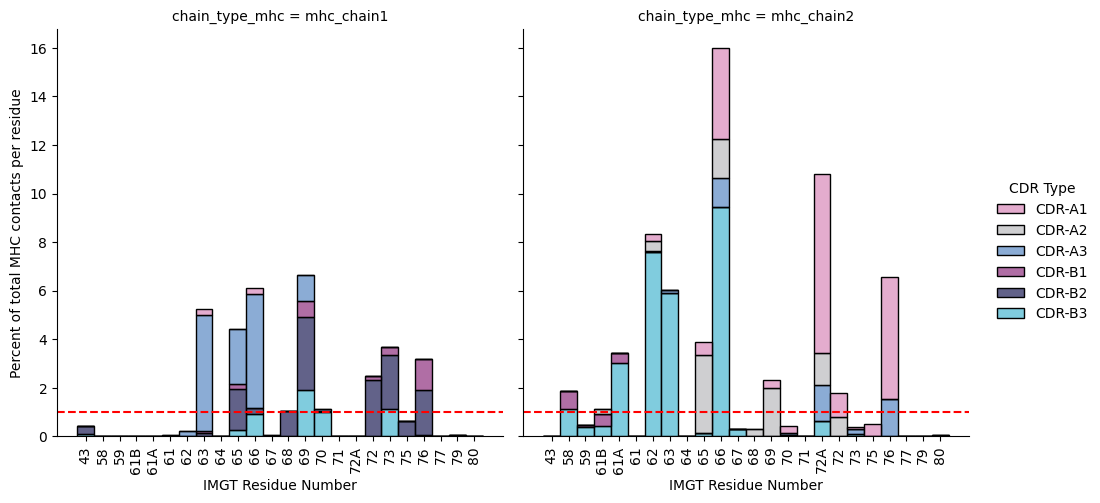

In [34]:
grid = sns.displot(
    mhc_ii_contacts.query("interface_type == 'tcr_mhc'").sort_values('residue_seq_id_mhc'),
    col='chain_type_mhc',
    x='resi_mhc',
    hue='cdr_name',
    multiple='stack',
    stat='percent',
    palette=palette,
)


for legend in grid.figure.legends:
    legend.set_title('CDR Type')

grid.set_axis_labels('IMGT Residue Number', 'Percent of total MHC contacts per residue')

for ax in grid.axes.flat:
    xlims = ax.get_xlim()
    ax.set_xlim(*xlims)
    ax.hlines(1, *xlims, color='red', linestyles='dashed')

    for label in ax.get_xticklabels():
        label.set_rotation(90)

plt.show()

In [35]:
mhc_labels = (
    mhc_ii_contacts[['residue_seq_id_mhc', 'residue_insert_code_mhc', 'resi_mhc']]
    .fillna('')
    .sort_values(['residue_seq_id_mhc', 'residue_insert_code_mhc'])['resi_mhc']
    .unique()
    .tolist()
)

tcr_labels = (
    mhc_ii_contacts[['residue_seq_id_tcr', 'residue_insert_code_tcr', 'resi_tcr']]
    .fillna('')
    .sort_values(['residue_seq_id_tcr', 'residue_insert_code_tcr'])['resi_tcr']
    .unique()
    .tolist()
)

mhc_ii_contacts['resi_mhc'] = pd.Categorical(mhc_ii_contacts['resi_mhc'], mhc_labels)
mhc_ii_contacts['resi_tcr'] = pd.Categorical(mhc_ii_contacts['resi_tcr'], tcr_labels)

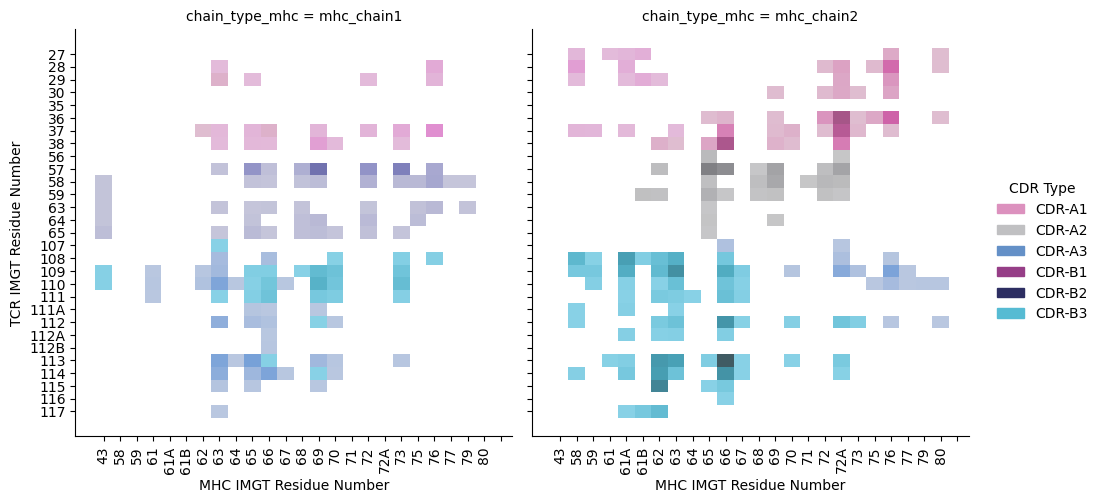

In [36]:
grid = sns.displot(
    mhc_ii_contacts.query("interface_type == 'tcr_mhc'").sort_values('chain_type_mhc'),
    col='chain_type_mhc',
    x='resi_mhc',
    y='resi_tcr',
    hue='cdr_name',
    palette=sns.color_palette(palette, 6),
)

for legend in grid.figure.legends:
    legend.set_title('CDR Type')

grid.set_axis_labels('MHC IMGT Residue Number', 'TCR IMGT Residue Number')

for ax in grid.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)

plt.show()

#### TCR Contacts on Peptides

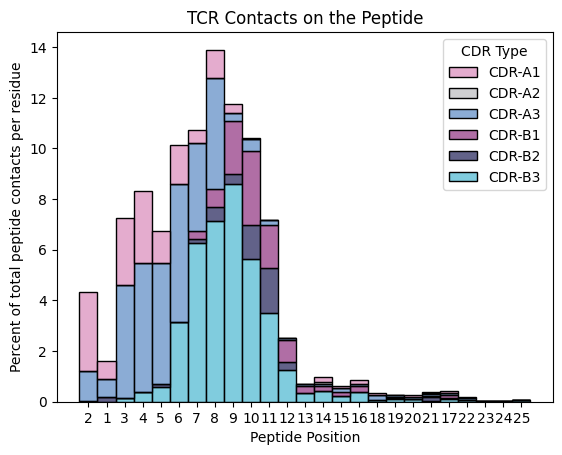

In [37]:
ax = sns.histplot(
    mhc_ii_contacts.query("interface_type == 'tcr_peptide'").sort_values('residue_seq_id_peptide'),
    x='peptide_position',
    hue='cdr_name',
    multiple='stack',
    stat='percent',
    palette=sns.color_palette(palette, 6),
)

ax.set_title('TCR Contacts on the Peptide')
ax.set_xlabel('Peptide Position')
ax.set_ylabel('Percent of total peptide contacts per residue')
ax.legend_.set_title(title='CDR Type')

plt.show()

<Axes: xlabel='peptide_length', ylabel='Count'>

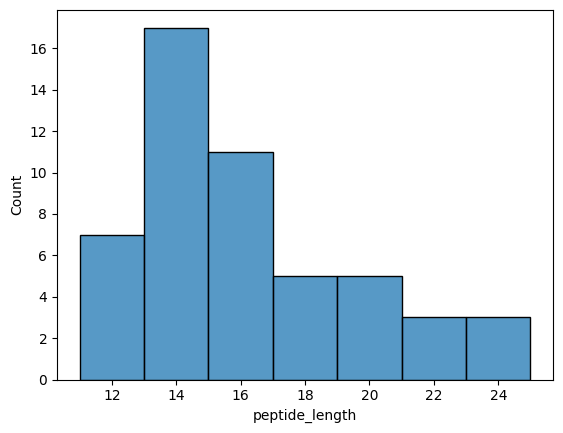

In [38]:
sns.histplot(mhc_ii_contacts.query("interface_type == 'tcr_peptide'").drop_duplicates('path'), x='peptide_length')

### Exporting residue list

In [39]:
mhc_ii_contact_positions = (
    mhc_ii_contacts.value_counts(['cdr_name', 'chain_type_mhc', 'resi_mhc'], normalize=True) * 100
)
mhc_ii_contact_positions.name = 'percentage'
mhc_ii_contact_positions = (
    mhc_ii_contact_positions.to_frame().reset_index().sort_values(['chain_type_mhc', 'resi_mhc']).reset_index(drop=True)
)

In [40]:
mhc_ii_contact_positions['cumulative_percentage'] = mhc_ii_contact_positions.groupby(['chain_type_mhc', 'resi_mhc'])[
    'percentage'
].transform('sum')

mhc_ii_contact_positions = mhc_ii_contact_positions[mhc_ii_contact_positions['cumulative_percentage'] >= 1.0]
mhc_ii_contact_positions = mhc_ii_contact_positions.reset_index(drop=True)
mhc_ii_contact_positions = mhc_ii_contact_positions.drop(columns=['cumulative_percentage'])

/var/scratch/bmcmaste/2399326/ipykernel_2018683/1183298924.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mhc_ii_contact_positions['cumulative_percentage'] = (mhc_ii_contact_positions.groupby(['chain_type_mhc', 'resi_mhc'])


In [41]:
mhc_ii_contact_positions

,cdr_name,chain_type_mhc,resi_mhc,percentage
0,CDR-A3,mhc_chain1,63,4.780387
1,CDR-A1,mhc_chain1,63,0.257436
2,CDR-B2,mhc_chain1,63,0.118817
3,CDR-B1,mhc_chain1,63,0.083172
4,CDR-B3,mhc_chain1,63,0.015842
...,...,...,...,...
61,CDR-A3,mhc_chain2,72A,1.477286
62,CDR-A2,mhc_chain2,72A,1.334706
63,CDR-B3,mhc_chain2,72A,0.641610
64,CDR-A1,mhc_chain2,76,5.053665


In [42]:
mhc_ii_contact_positions.to_csv('data/interim/tcr_mhc_class_II_contacts.csv', index=False)